In [1]:
import os
print(os.environ['CONDA_DEFAULT_ENV'])

import sys
print("User Current Version:-", sys.version)

sctl
User Current Version:- 3.10.17 | packaged by conda-forge | (main, Apr 10 2025, 22:19:12) [GCC 13.3.0]


In [2]:
'''


This notebook preprosses single cell data from cell ranger output to clutering .

THe same pbmc3k data used in the seurat tutorial is used as an example  

It largely follows the scanpy tutorial 
https://scanpy-tutorials.readthedocs.io/en/latest/pbmc3k.html


'''

'\n\n\nThis notebook preprosses single cell data from cell ranger output to clutering .\n\nTHe same pbmc3k data used in the seurat tutorial is used as an example  \n\nIt largely follows the scanpy tutorial \nhttps://scanpy-tutorials.readthedocs.io/en/latest/pbmc3k.html\n\n\n'

With the exceptions of *IL7R*, which is only found by the t-test and *FCER1A*, which is only found by the other two appraoches, all marker genes are recovered in all approaches.

Louvain Group | Markers | Cell Type
---|---|---
0 | IL7R | CD4 T cells
1 | CD14, LYZ | CD14+ Monocytes
2 | MS4A1 |	B cells
3 | CD8A |	CD8 T cells
4 | GNLY, NKG7 | 	NK cells
5 | FCGR3A, MS4A7 |	FCGR3A+ Monocytes
6 | FCER1A, CST3 |	Dendritic Cells
7 | PPBP |	Megakaryocytes

# load modules / paths / set dataset parameters

In [3]:
#!mkdir data
#!wget http://cf.10xgenomics.com/samples/cell-exp/1.1.0/pbmc3k/pbmc3k_filtered_gene_bc_matrices.tar.gz -O data/pbmc3k_filtered_gene_bc_matrices.tar.gz
#!cd data; tar -xzf pbmc3k_filtered_gene_bc_matrices.tar.gz
#!mkdir write


In [4]:
# suppress future warnings
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [5]:
!pwd

/efs/general/blewis/projects/gitbenlewis/single_cell_python_tools/Example_notebooks/01_PBMC3k


## libraries standard paths and settings

In [6]:
# save all the global variable in a dataclass G
from dataclasses import dataclass
@dataclass
class G():
    '''Class to hold global variables'''
    write_dir='/home/ubuntu/write/'
    repo_parent_dir='/home/ubuntu/projects/'
    WRITE_CACHE=False
    #input files
    # download http
    dataset_download_http='http://cf.10xgenomics.com/samples/cell-exp/1.1.0/pbmc3k/pbmc3k_filtered_gene_bc_matrices.tar.gz'

    #output files
    import os 
    # make directory in the data directory
    #data_download_dir='./data/filtered_gene_bc_matrices/hg19/'
    #os.makedirs(data_download_dir,exist_ok=True)


    #variables to change
    save_output=True
    save_output_figures=True

    

In [7]:
#write_dir='/home/ubuntu/write/'
#repo_parent_dir='../../'

import sys
if G.repo_parent_dir not in sys.path:
    sys.path.append(G.repo_parent_dir)

In [8]:
# improt favorite local packages

import single_cell_python_tools as sctl
print(sctl.DATASET_class.__doc__) # access DATASET_class via sctl.DATASET_class
from single_cell_python_tools.DATASET_class import *
print(DATASET_class.__doc__) # after to current namespace access DATASET_class via DATASET_class



End-to-end single-cell workflow with a central *parameters* dictionary..
End-to-end single-cell workflow with a central *parameters* dictionary..


In [9]:
import sys
sys.path.append('./') # to look for the nb_config.py file in the parent directory
sys.path.append('../') # to look for the nb_config.py file in the grand parent directory
sys.path.append('../../') # to look for the nb_config.py file in the grand parent directory

import nb_config
from nb_config import *

#import sc_utils 
#from sc_utils import *

'''
import os
import sys
# import pandas try
try:
    import pandas as pd
    # pandas display options
    pd.set_option('display.max_rows', 500)
    pd.set_option('display.max_columns', 500)
    pd.set_option('display.width', 1000)
    pd.options.display.max_seq_items = 2000
except ImportError as e:
    print(f"pandas import Error: {e}")

# import numpy, seaborn and matplotlib
try:
    import numpy as np
    import seaborn as sns
    import matplotlib.pyplot as plt
    %matplotlib inline
    # Custom colormap where lowest values are represented by grey good for umaps
    import matplotlib.colors as mcolors
    cmap = mcolors.ListedColormap(['gray'] + list(plt.cm.viridis(np.linspace(0, 1, 256))))
except ImportError as e:
    print(f"numpy, seaborn or matplotlib import Error: {e}")

# import scanpy
try:
    import scanpy as sc
    import anndata as ad
    # scanpy options
    sc.settings.verbosity = 1             # verbosity: errors (0), warnings (1), info (2), hints (3)
    sc.logging.print_header()
    sc.settings.set_figure_params(dpi=80, facecolor='white')
    #WRITE_CACHE=False # use false if  in github repo or cache files not in git ignore
except ImportError as e:
    print(f"scanpy import Error: {e}")   

 '''

'\nimport os\nimport sys\n# import pandas try\ntry:\n    import pandas as pd\n    # pandas display options\n    pd.set_option(\'display.max_rows\', 500)\n    pd.set_option(\'display.max_columns\', 500)\n    pd.set_option(\'display.width\', 1000)\n    pd.options.display.max_seq_items = 2000\nexcept ImportError as e:\n    print(f"pandas import Error: {e}")\n\n# import numpy, seaborn and matplotlib\ntry:\n    import numpy as np\n    import seaborn as sns\n    import matplotlib.pyplot as plt\n    %matplotlib inline\n    # Custom colormap where lowest values are represented by grey good for umaps\n    import matplotlib.colors as mcolors\n    cmap = mcolors.ListedColormap([\'gray\'] + list(plt.cm.viridis(np.linspace(0, 1, 256))))\nexcept ImportError as e:\n    print(f"numpy, seaborn or matplotlib import Error: {e}")\n\n# import scanpy\ntry:\n    import scanpy as sc\n    import anndata as ad\n    # scanpy options\n    sc.settings.verbosity = 1             # verbosity: errors (0), warnings (1)

In [10]:

%matplotlib inline 

## common parameters for dataset

In [11]:
pbmc3k_parameters={

"download_url":'http://cf.10xgenomics.com/samples/cell-exp/1.1.0/pbmc3k/pbmc3k_filtered_gene_bc_matrices.tar.gz',
"download_output_dir":'./data/',
"download_output_filename": None,
"input_file_path":'./data/',
'file_format':'10x',


"output_prefix":'EX_pbmc3k_raw_sctl_DATASET_',
"output_dir":'./write/',

    
"n_jobs": 16,
#### dataset specfic parameters
###Basic filters
"filter_genes_min_cells":3,  # min of cells a gene is detected in else gene is tossed out default 3
"filter_genes_min_counts":0, # min  of counts a gene must have to pass basic filter default 0
"filter_cells_min_genes":200, # min  of genes detected or else cell/observation is tossed out default 200
"filter_cells_min_counts":0, # min  of counts detected or else cell/observation is tossed out default 0  
    
####Filter  on off switches
"filter_ncount" : True,
"filter_pct_mt" : True,
"filter_pct_ribo" : False,
"filter_pct_hb" : False,
"filter_pct_malat1":False,
"filter_HVG" : True,

###less than filter percent 
"n_genes_bycounts" : 2500, #less than filter
"percent_mt" : 5, #less than filter
"percent_ribo" : 100, #less than filter
"percent_malat1": 100, #less than filter
"percent_hb" : 100,  #less than filter

###Greater than filter percent
"over_n_genes_bycounts" : 200, #greater than filter
"over_percent_mt" : 0, #greater than filter
"over_percent_ribo" : 0, #greater than filter
"over_percent_malat1": 0, #greater than filter
"over_percent_hb" : 0 , #greater than filter

###Remove gene sets  on off switches
"remove_MALAT1" : False, 
"remove_MT" : False ,
"remove_HB" : False,
"remove_RP_SL" : False ,
"remove_MRP_SL" : False,

#### processing parameters and options
"filter_genes_min_counts_normed":0,
"normalize_total_target_sum" : 1e4,  # scanpy  default 1e4
"HVG_min_mean"  :  0.0125, # scanpy  default 0.0125
"HVG_max_mean"  :  3, # scanpy  default 3
"HVG_min_disp"  :  0.5, # scanpy  default 0.5
"logarithmize":True, # scanpy default True
"scale":True, # scanpy default True
"scale_max_std_value":10, # 10 often used
    
####regression on off switches
"regress_mt" : True,
"regress_ribo" : False,
"regress_malat1":False,
"regress_hb" : False,
"regress_cell_cycle_score" : False,

###clustering parameters for clusters
"number_of_PC" : 40, ### dataset demensionality 
"number_of_neighbors" : 10,
"leiden_res" : .9, #leiden clustering resolution


# UMAP graph parameters
'umap_marker_gene':True,
'umap_marker_gene_list': ['IL7R','CD14','LYZ', 'MS4A1','CD8A','GNLY','NKG7','FCGR3A','MS4A7','FCER1A','CST3','PPBP'],
'ncols': 4,
'vmax':None,
#cluster naming parameters
'rename_cluster': True,
####  'NK' and 'FCGR3A Monocytes' seem to switch places sometimes .. not sure if its random or a bug, NK cluster should be close to CD8 T cells
#'new_cluster_names' : [  'CD4 T', 'CD14 Monocytes', 'B','CD8 T',   'FCGR3A Monocytes','NK','Dendritic', 'Megakaryocytes'],
'new_cluster_names' : [  'CD4 T', 'CD14 Monocytes', 'B','CD8 T',   'NK','FCGR3A Monocytes','Dendritic', 'Megakaryocytes'],  

}


parameters=pbmc3k_parameters.copy()

# use sctl.DATASET_class class to do the single cell analysis

### first lets try some doc strings for methods of the sctl.DATASET_class class

In [12]:
print(sctl.DATASET_class.__doc__)

End-to-end single-cell workflow with a central *parameters* dictionary..


##  instantiate sctl.DATASET_class with and parameters 

In [13]:
pbmc3k_sctl_DATASET=sctl.DATASET_class(parameters=pbmc3k_parameters)


2025-04-29 17:24:54,966 | sctl.DATASET_class | INFO | sctl_DATASET_class initialized with parameters:
2025-04-29 17:24:54,967 | sctl.DATASET_class | INFO |  self.download_url http://cf.10xgenomics.com/samples/cell-exp/1.1.0/pbmc3k/pbmc3k_filtered_gene_bc_matrices.tar.gz
2025-04-29 17:24:54,968 | sctl.DATASET_class | INFO |  self.download_output_dir ./data/
2025-04-29 17:24:54,968 | sctl.DATASET_class | INFO |  self.download_output_filename None
2025-04-29 17:24:54,969 | sctl.DATASET_class | INFO |  self.input_file_path ./data/
2025-04-29 17:24:54,970 | sctl.DATASET_class | INFO |  self.output_prefix EX_pbmc3k_raw_sctl_DATASET_
2025-04-29 17:24:54,970 | sctl.DATASET_class | INFO |  self.output_dir ./write/


##  download the data and unpack it with methods : .download_data().unpack_tar()

In [14]:
pbmc3k_sctl_DATASET.download_data().unpack_tar()
# if data is already downloaded and unpacked
# set path the unpacked data directory
#pbmc3k_sctl_DATASET.path='data/filtered_gene_bc_matrices/hg19/'

2025-04-29 17:24:54,982 | sctl.DATASET_class | INFO | Running download command:
wget -nv --content-disposition --trust-server-names -P ./data/ http://cf.10xgenomics.com/samples/cell-exp/1.1.0/pbmc3k/pbmc3k_filtered_gene_bc_matrices.tar.gz
2025-04-29 17:24:55,418 | sctl.DATASET_class | INFO | Download complete.
2025-04-29 17:24:55,518 | sctl.DATASET_class | INFO | filename inferred from headers: None
2025-04-29 17:24:55,519 | sctl.DATASET_class | WARNING | Falling back to filename from URL: pbmc3k_filtered_gene_bc_matrices.tar.gz
2025-04-29 17:24:55,525 | sctl.DATASET_class | INFO | Downloaded to ./data/pbmc3k_filtered_gene_bc_matrices.tar.gz (inferred from headers)
2025-04-29 17:24:55,527 | sctl.DATASET_class | INFO | Extracting data/pbmc3k_filtered_gene_bc_matrices.tar.gz → data …
2025-04-29 17:24:56,265 | sctl.DATASET_class | INFO | Set self.path to directory containing 'barcodes': data/filtered_gene_bc_matrices/hg19
2025-04-29 17:24:56,266 | sctl.DATASET_class | INFO | Extracted 5 f

## load and process the downloaded the data (10x format) 

In [15]:
pbmc3k_sctl_DATASET.load_data()

2025-04-29 17:24:56,939 | sctl.DATASET_class | INFO | Loaded 10X data from data/filtered_gene_bc_matrices/hg19 with no prefix
2025-04-29 17:24:56,941 | sctl.DATASET_class | INFO | Loaded data with 2700 observations and 32738 variables
2025-04-29 17:24:56,941 | sctl.DATASET_class | INFO | self.adata 
AnnData object with n_obs × n_vars = 2700 × 32738
    var: 'gene_ids'
    uns: 'parameters'


### QC

2025-04-29 17:24:56,954 | sctl.pp._qc | INFO |  2700 observations BEFORE Basic Filtering (min_genes and min_counts)
2025-04-29 17:24:57,009 | sctl.pp._qc | INFO |  Filtering cells  sc.pp.filter_cells(adata, min_genes=200)
2025-04-29 17:24:57,011 | sctl.pp._qc | INFO |  2700 observations AFTER  min_genes Filtering, min_genes=200
2025-04-29 17:24:57,044 | sctl.pp._qc | INFO |  Filtering cells sc.pp.filter_cells(adata,min_counts=0)
2025-04-29 17:24:57,045 | sctl.pp._qc | INFO |  2700 observations AFTER min_counts Filtering, min_counts=0
2025-04-29 17:24:57,046 | sctl.pp._qc | INFO |  32738 features BEFORE Basic Filtering (min_cells and min_counts)
2025-04-29 17:24:57,072 | sctl.pp._qc | INFO |  Filtering cells  sc.pp.filter_genes(adata, min_cells=3)
2025-04-29 17:24:57,073 | sctl.pp._qc | INFO |  13714 observations AFTER  min_genes Filtering, min_genes=3
2025-04-29 17:24:57,089 | sctl.pp._qc | INFO |  Filtering cells  sc.pp.filter_genes(adata, min_counts=0)
2025-04-29 17:24:57,090 | sctl.

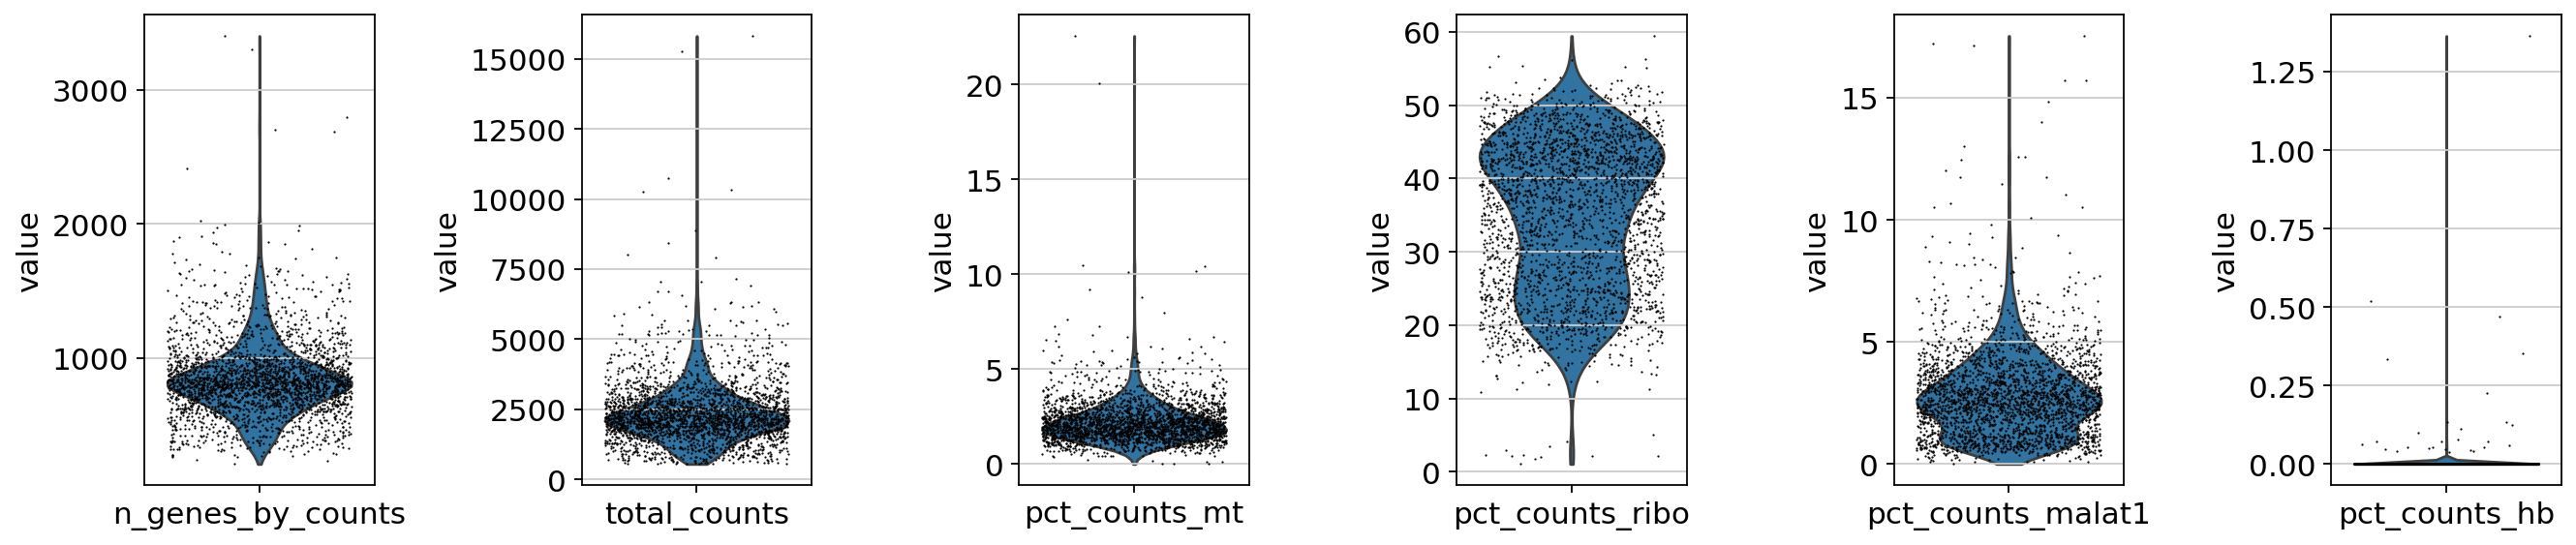

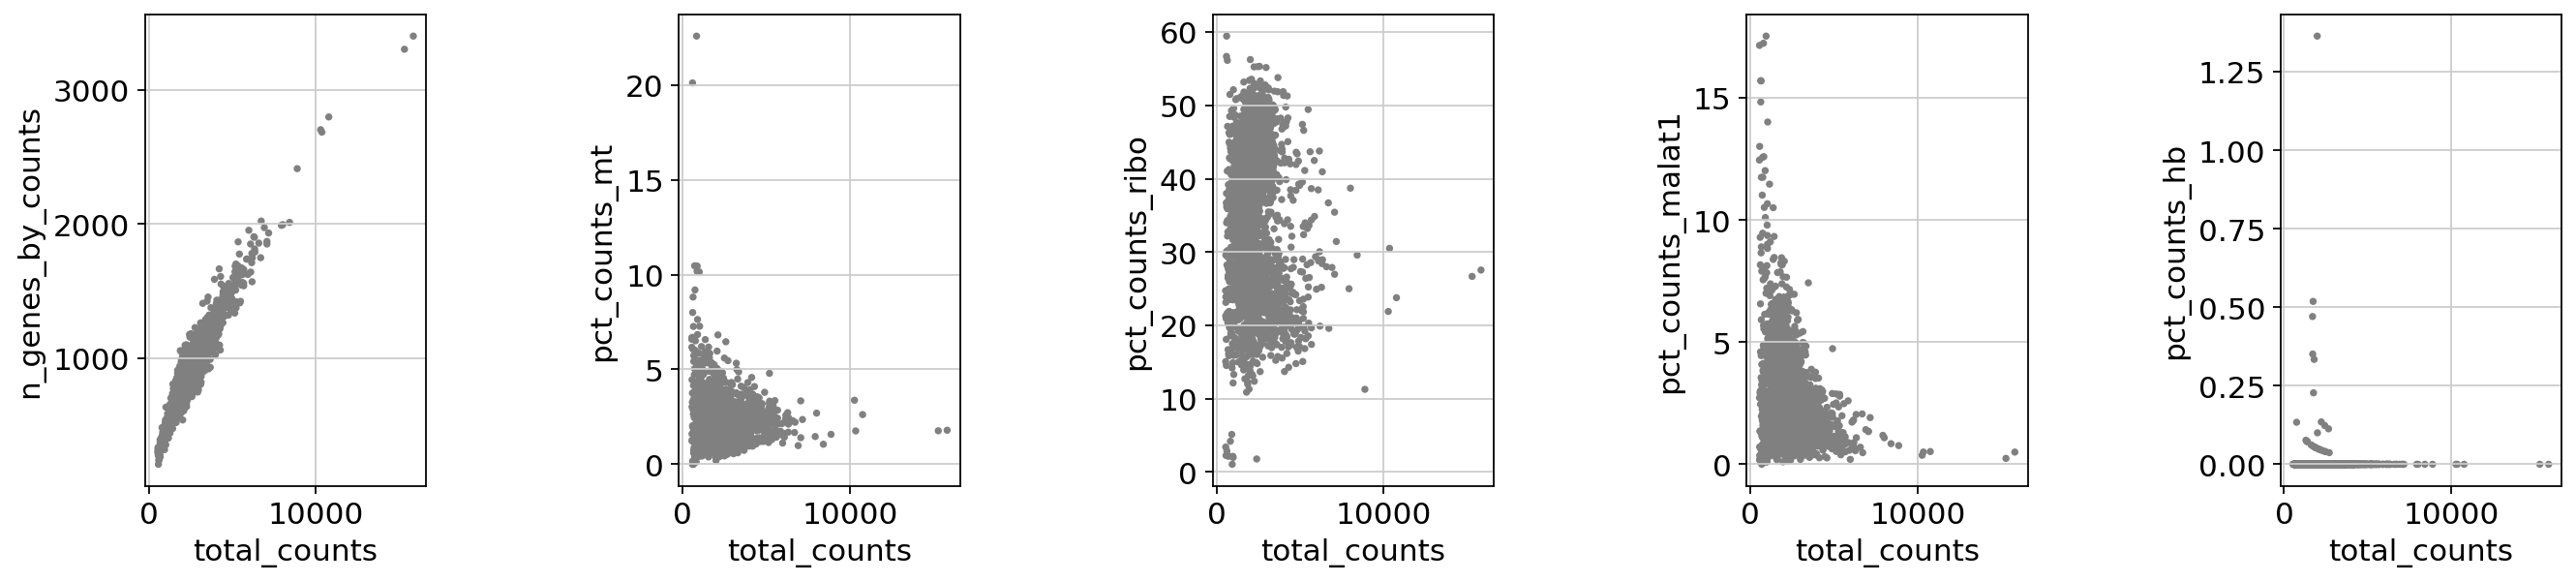

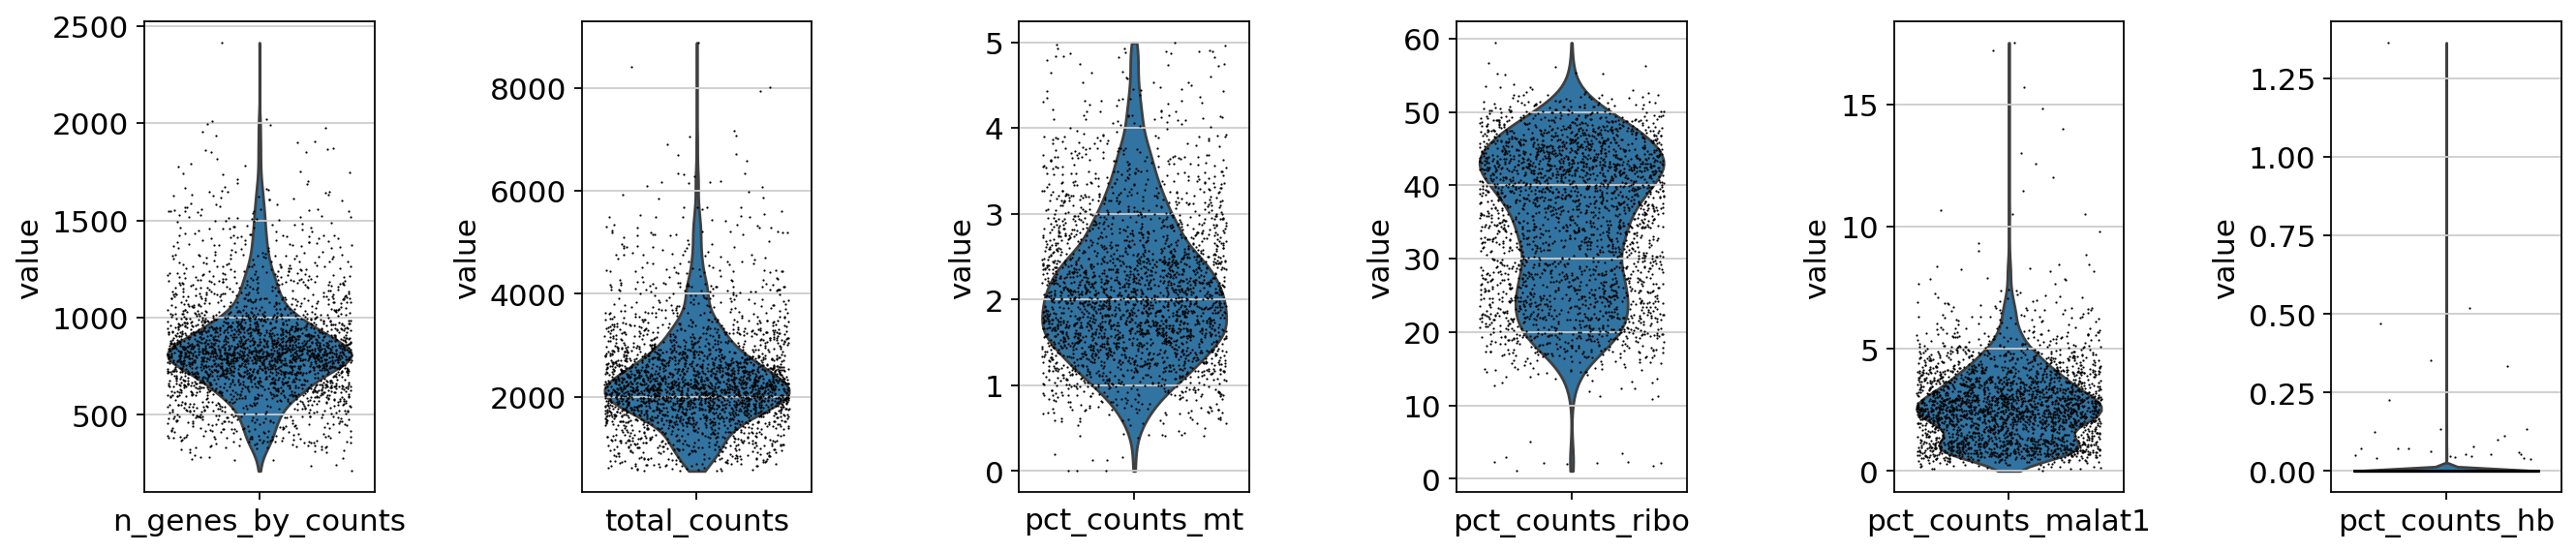

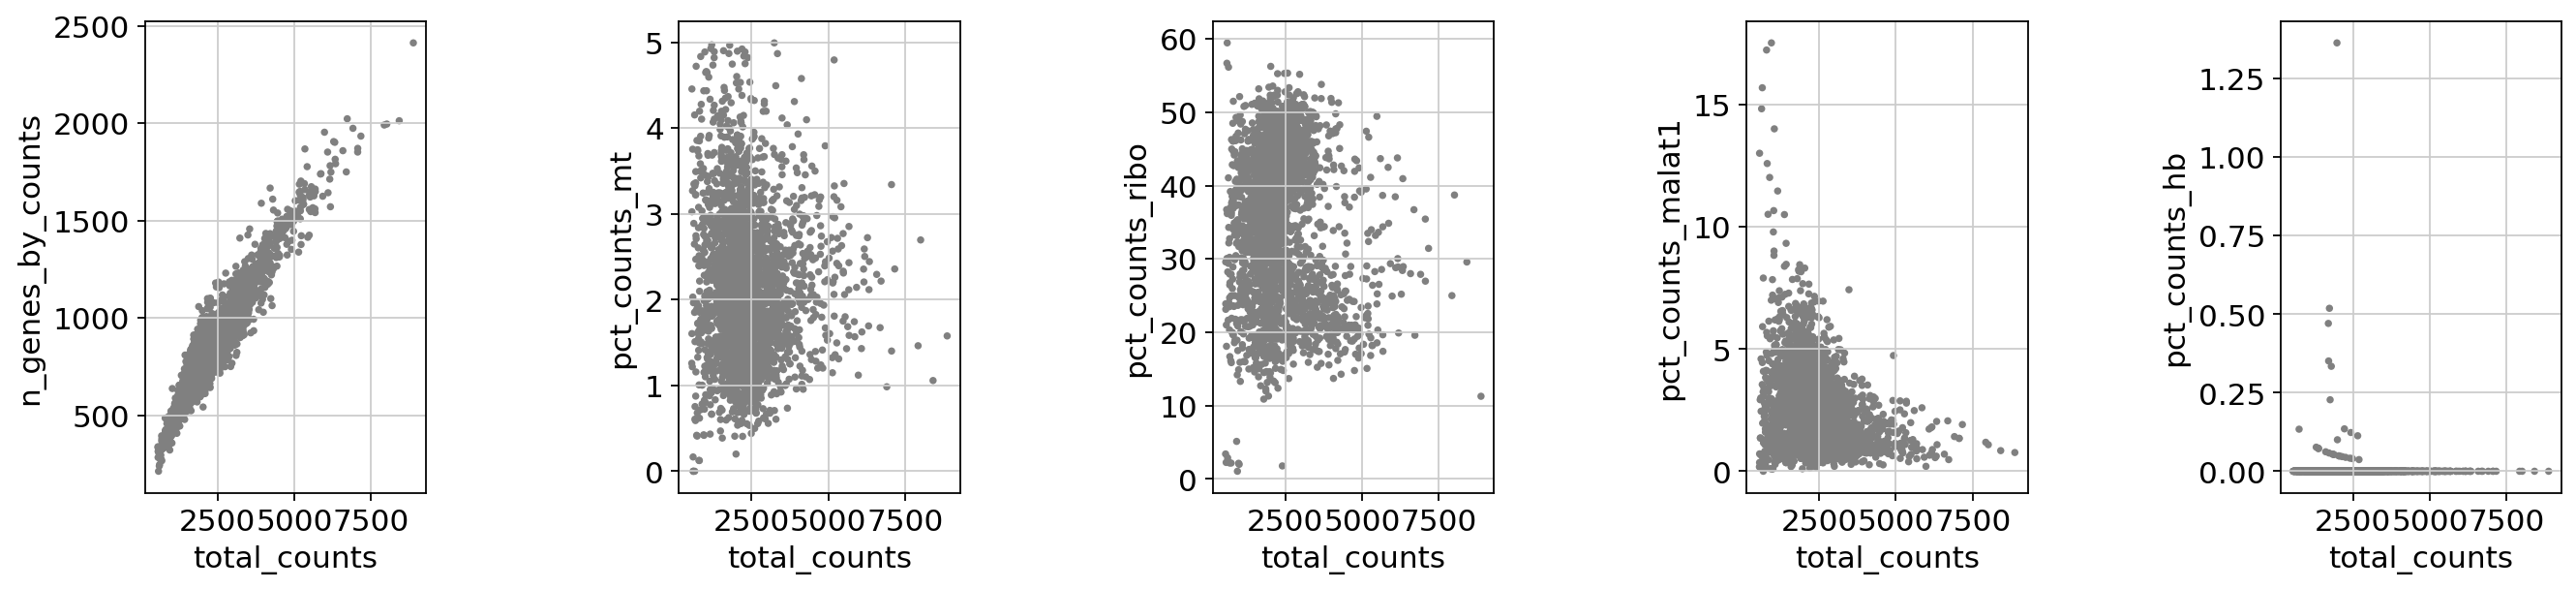

In [16]:
### QC
pbmc3k_sctl_DATASET.basic_filitering()
pbmc3k_sctl_DATASET.annotate_n_view_adata_raw_counts()
pbmc3k_sctl_DATASET.filter_cells_by_anotated_QC_gene()
pbmc3k_sctl_DATASET.remove_genes()
pbmc3k_sctl_DATASET.annotate_n_view_adata_raw_counts()

### data transforms and clustering

2025-04-29 17:25:03,745 | sctl.pp._transform_data | INFO |  running process2scaledPCA adata at start 
 AnnData object with n_obs × n_vars = 2638 × 13714
    obs: 'n_genes', 'n_counts', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'pct_counts_hb', 'total_counts_malat1', 'pct_counts_malat1'
    var: 'gene_ids', 'n_cells', 'n_counts', 'mt', 'ribo', 'hb', 'malat1', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
    uns: 'parameters'
2025-04-29 17:25:03,746 | sctl.pp._transform_data | INFO | Step 1) library-size correct and Logarithmize (optional) the data 
2025-04-29 17:25:03,747 | sctl.pp._transform_data | INFO | 10000.0 : normalize_total_target_sum 
2025-04-29 17:25:03,750 | sctl.pp._transform_data | INFO | True : Logarithmize (optional) the data 
2025-04-29 17:25:03,751 | sctl.pp._transform_data | INFO | sctl.pp.norm_log() 
2025-04-29 17:25:03,752 | sctl.pp._transform_data

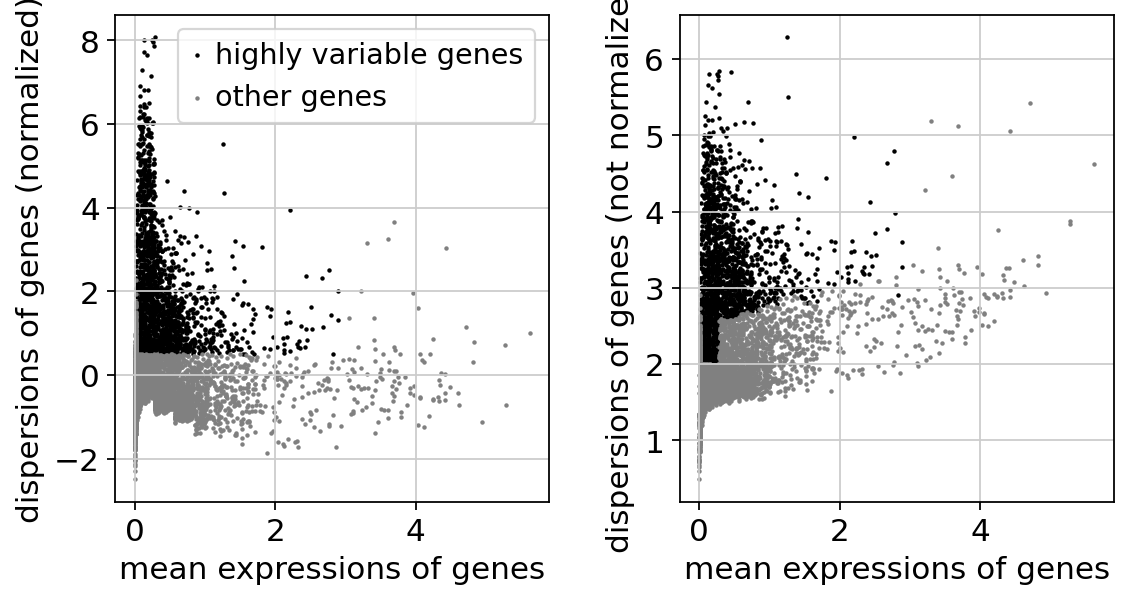

2025-04-29 17:25:04,395 | sctl.pp._transform_data | INFO | 1838 : number of highly varriable genes 
2025-04-29 17:25:04,395 | sctl.pp._transform_data | INFO |  13714 features BEFORE filtering for highly_variable genes
2025-04-29 17:25:04,397 | sctl.pp._transform_data | INFO |  filter_HVG = True ... only highly_variable gene will be kept 
2025-04-29 17:25:04,404 | sctl.pp._transform_data | INFO |  1838 features AFTER filtering for highly_variable genes
2025-04-29 17:25:04,405 | sctl.pp._transform_data | INFO | Step 2) regress_out_anotated_QC_genes (optional)
2025-04-29 17:25:04,406 | sctl.pp._transform_data | INFO | ####################################################  regress_out_anotated_QC_genes 
2025-04-29 17:25:04,406 | sctl.pp._transform_data | INFO | True (optional) regressing out  total_counts 
2025-04-29 17:25:04,407 | sctl.pp._transform_data | INFO | True (optional) regressing out  pct_counts_mt
2025-04-29 17:25:04,408 | sctl.pp._transform_data | INFO | False (optional) regres

/home/ubuntu/miniconda3/envs/sctl/lib/python3.10/site-packages/scanpy/preprocessing/_simple.py:710: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


2025-04-29 17:25:04,698 | sctl.pp._transform_data | INFO | Step 4) cell cycle score (optional)  
2025-04-29 17:25:04,699 | sctl.pp._transform_data | INFO |  True : calculate cell cycle score (optional) 
2025-04-29 17:25:04,704 | sctl.pp._transform_data | INFO |  False : regressing out cell cycle score (optional) 
2025-04-29 17:25:04,705 | sctl.pp._transform_data | INFO | running sctl.pp.calc_cell_cycle_score(adata,organism=human) 
2025-04-29 17:25:04,706 | sctl.pp._transform_data | INFO | ############# WARNING data should be scaled first if planing on regressing out cell cycle score
2025-04-29 17:25:04,706 | sctl.pp._transform_data | INFO | Organism is human, using  human cell cycle genes
2025-04-29 17:25:04,707 | sctl.pp._transform_data | INFO |  there are 43 s_genes   54 g2m_genes  97 cell_cycle_genes
2025-04-29 17:25:04,708 | sctl.pp._transform_data | INFO |  there are 7 cell_cycle_genes in the dataset


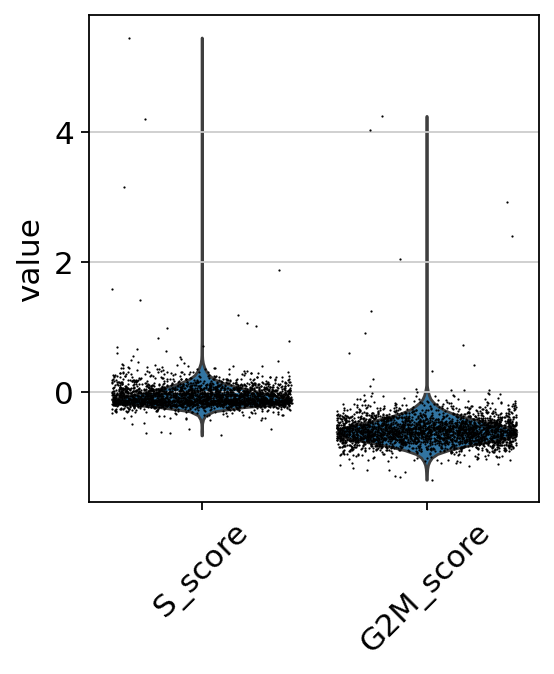

2025-04-29 17:25:05,134 | sctl.pp._transform_data | INFO | Step 5) PCA analysis   
2025-04-29 17:25:05,134 | sctl.pp._transform_data | INFO |  Principal component analysis, results stored in adata.obsm["X_pca"]
2025-04-29 17:25:05,135 | sctl.pp._transform_data | INFO | running sc.tl.pca(adata, svd_solver='arpack')
2025-04-29 17:25:05,136 | sctl.pp._transform_data | INFO | plotting variance ratio sc.pl.pca_variance_ratio(adata, log=True)


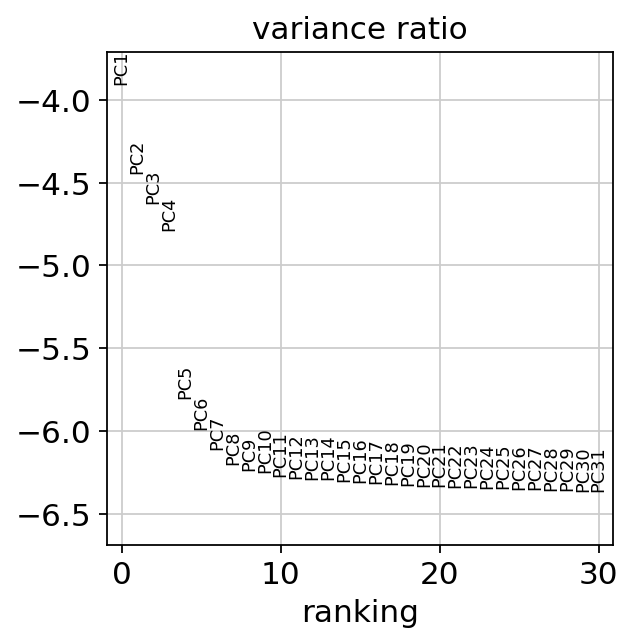

2025-04-29 17:25:08,969 | sctl.pp._transform_data | INFO | Done : process2scaledPCA adata AFTER 
 AnnData object with n_obs × n_vars = 2638 × 1838
    obs: 'n_genes', 'n_counts', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'pct_counts_hb', 'total_counts_malat1', 'pct_counts_malat1', 'S_score', 'G2M_score', 'phase'
    var: 'gene_ids', 'n_cells', 'n_counts', 'mt', 'ribo', 'hb', 'malat1', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'parameters', 'log1p', 'hvg', 'pca'
    obsm: 'X_pca'
    varm: 'PCs'
    layers: 'counts'


/home/ubuntu/miniconda3/envs/sctl/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


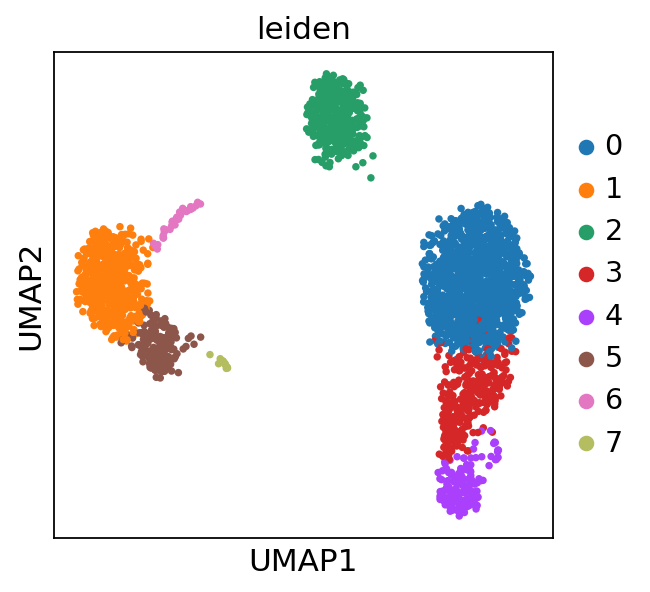

In [17]:
### data transforms and clustering
pbmc3k_sctl_DATASET.process2scaledPCA()
pbmc3k_sctl_DATASET.leiden_clustering()
pbmc3k_sctl_DATASET.rename_leiden_clusters()

### UMAP plots

2025-04-29 17:25:25,180 | sctl.pl._plots | INFO |  Average silhoutte score = 0.12671756744384766 for 8 clusters at leiden resolution of 0.9


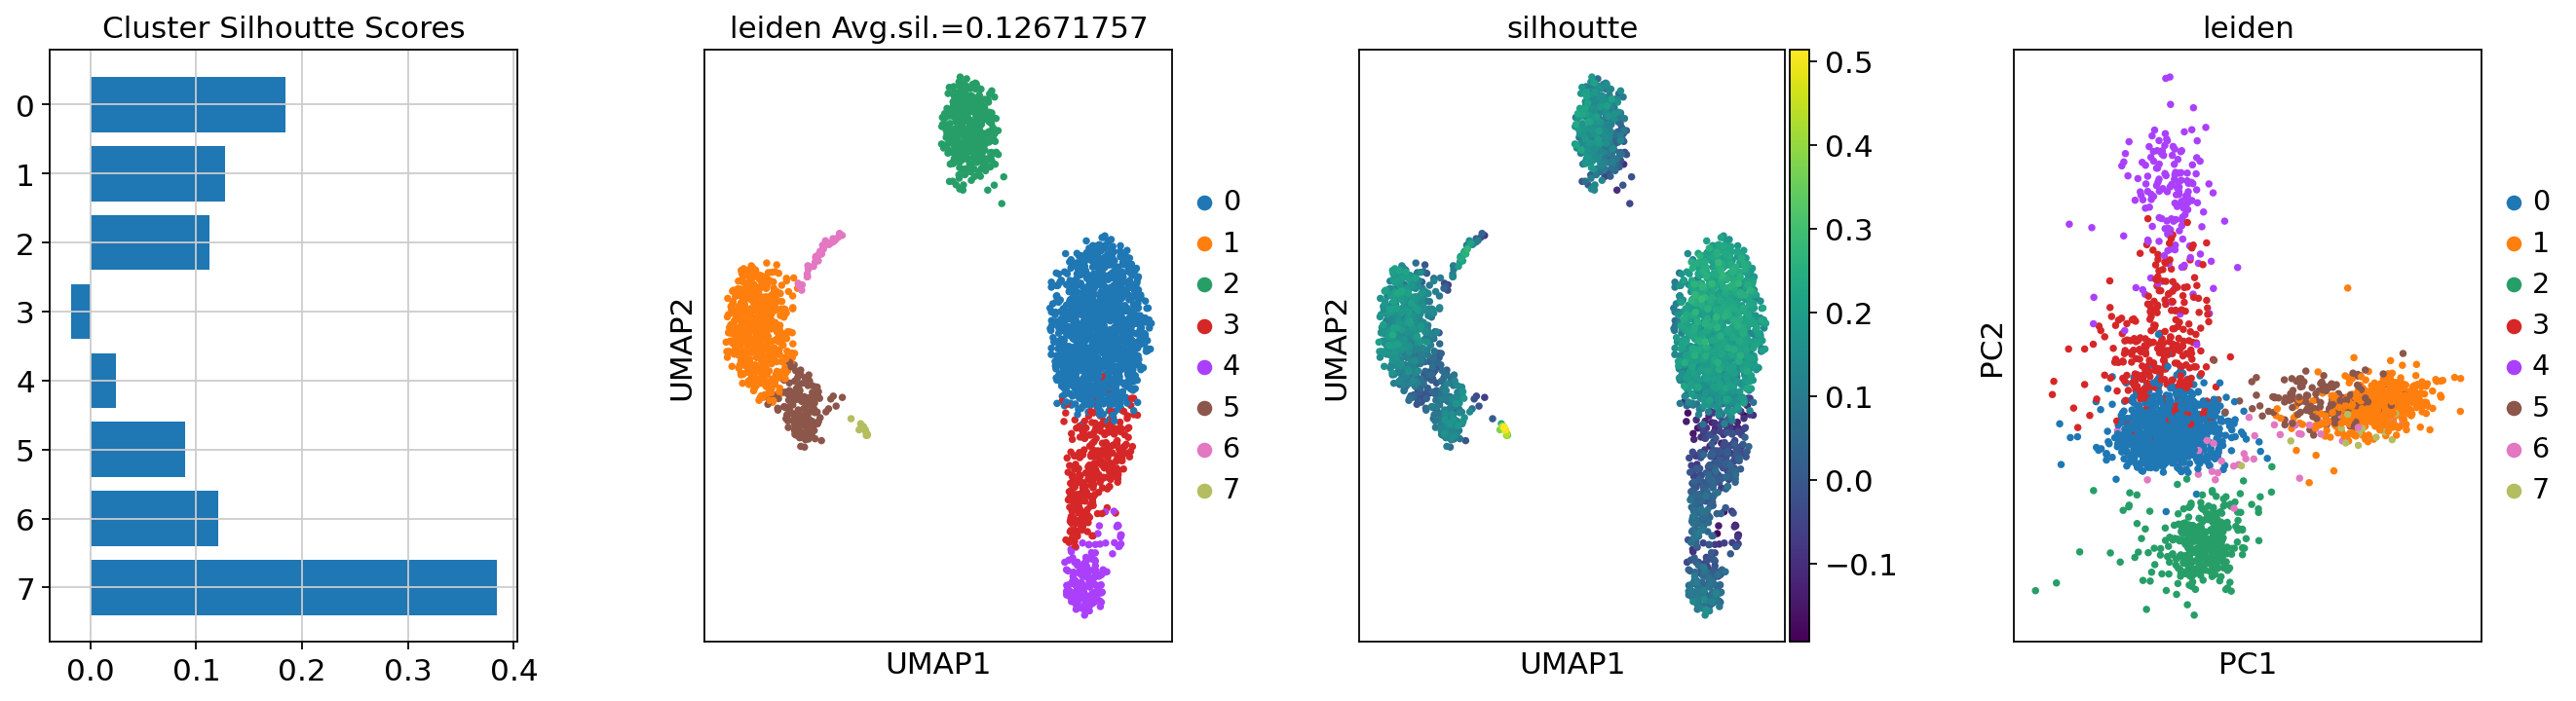

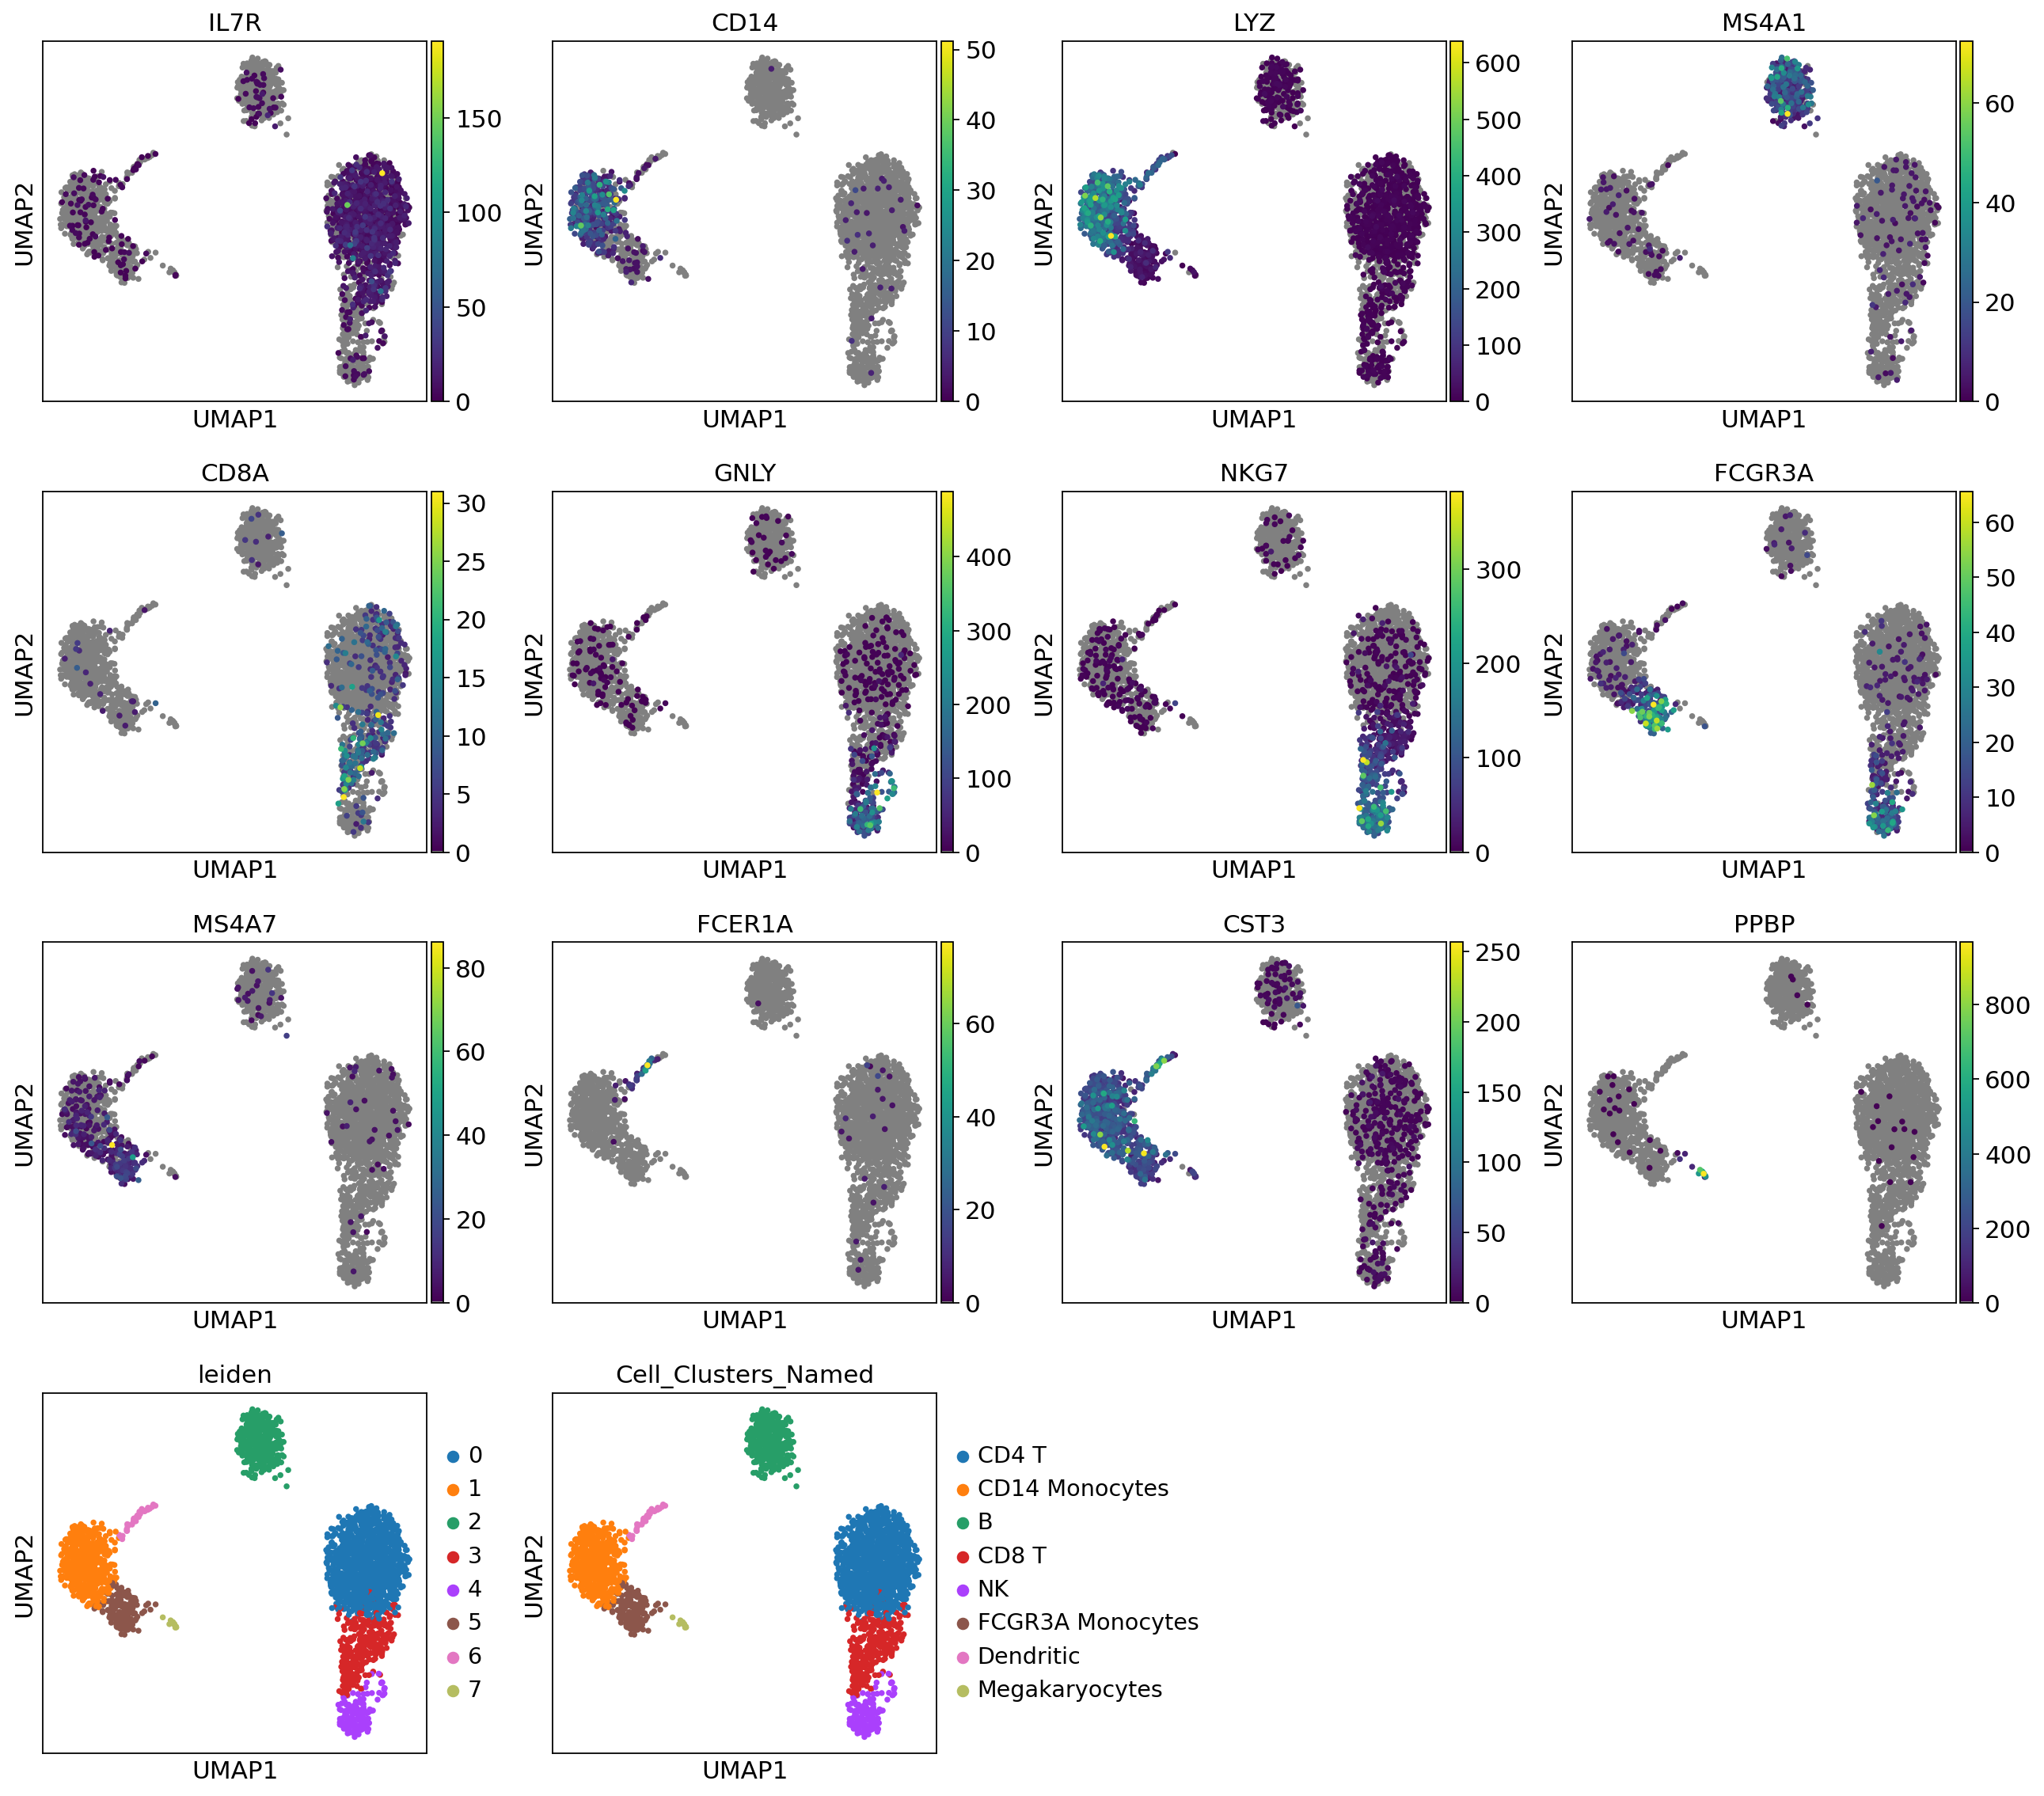

In [18]:

### UMAP plots
pbmc3k_sctl_DATASET.silhouette_score_n_plot()
pbmc3k_sctl_DATASET.marker_gene_umaps(palette=None)

## run sctl.tl.rank_genes() 

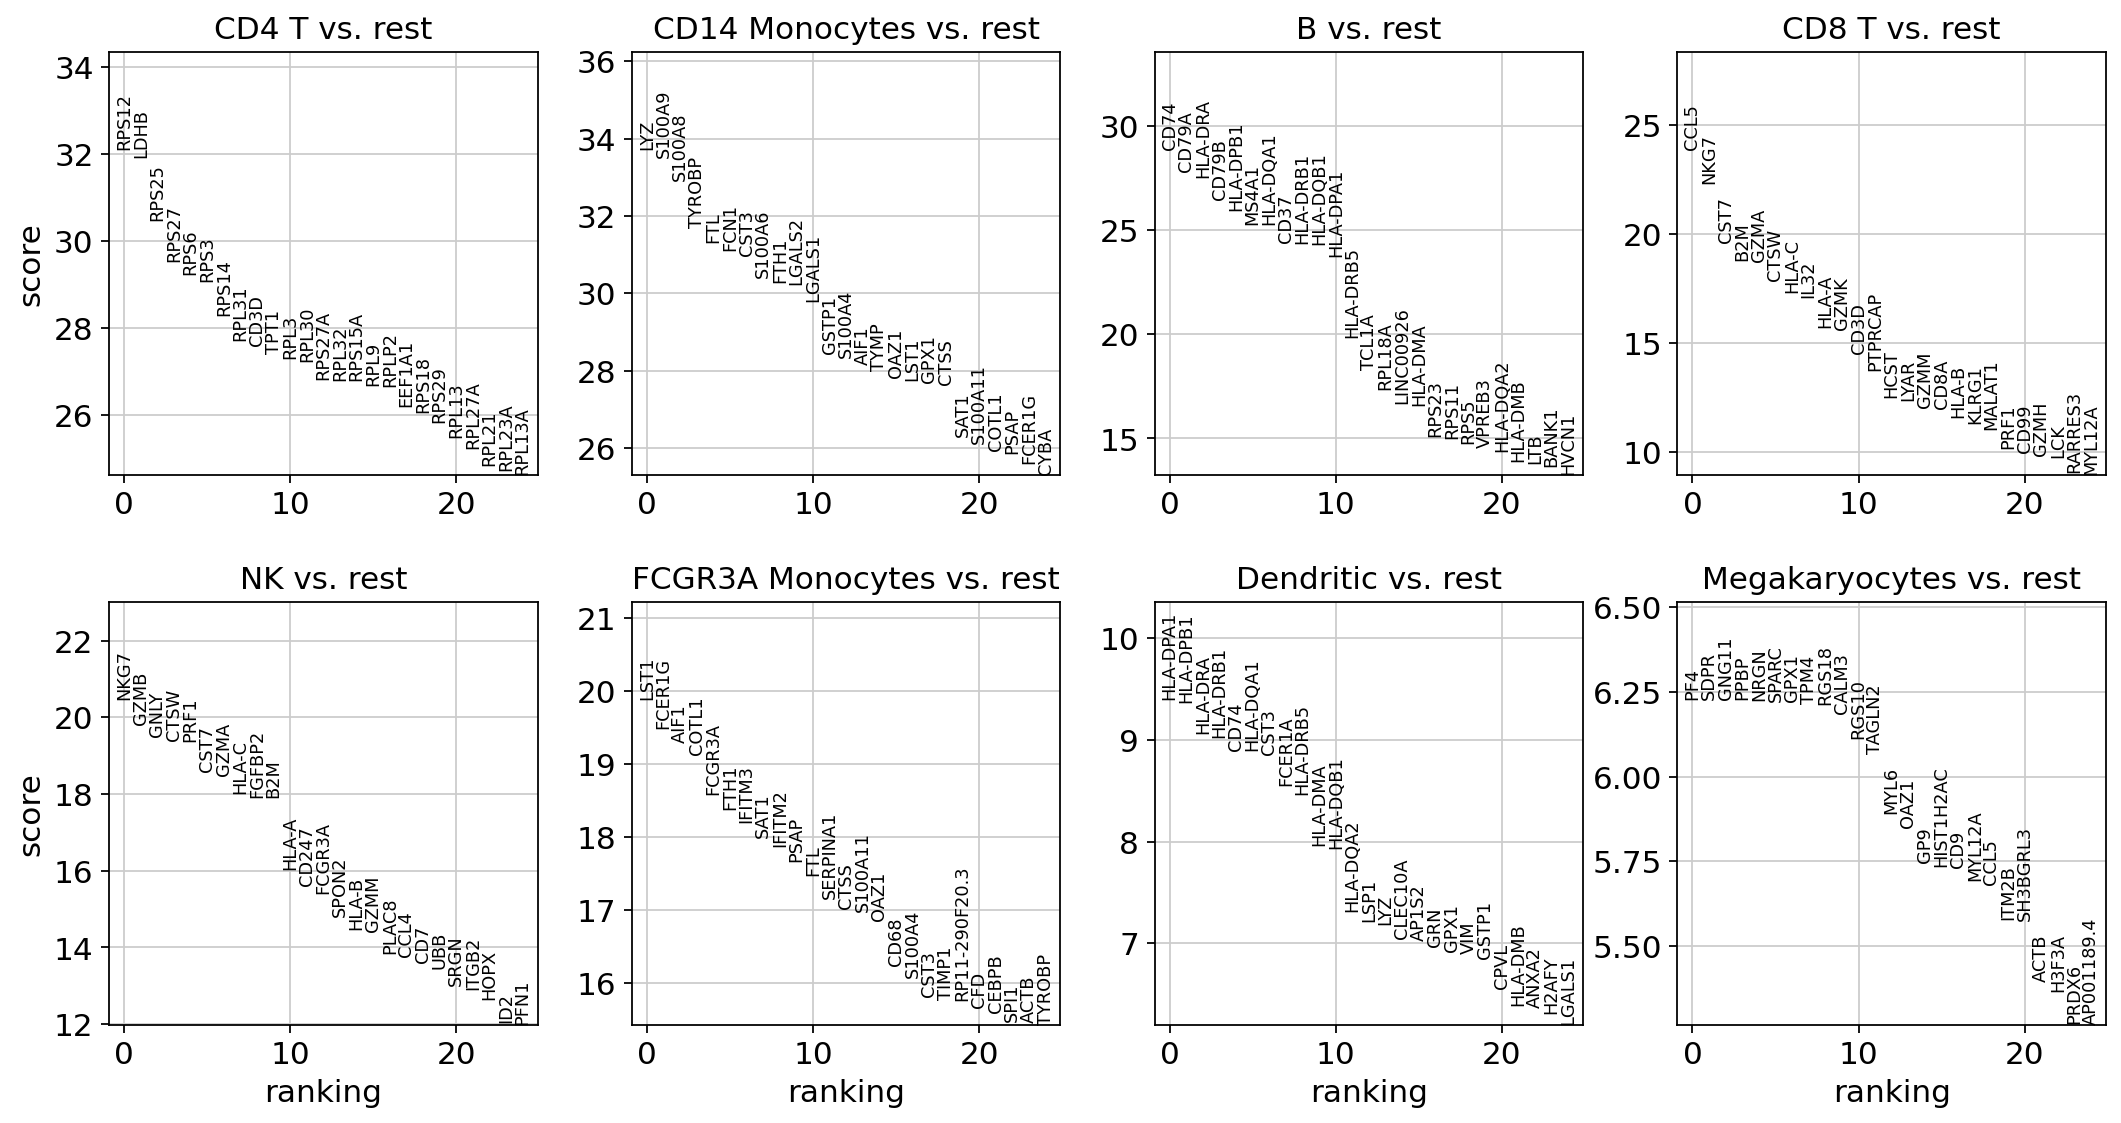

/home/ubuntu/.local/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


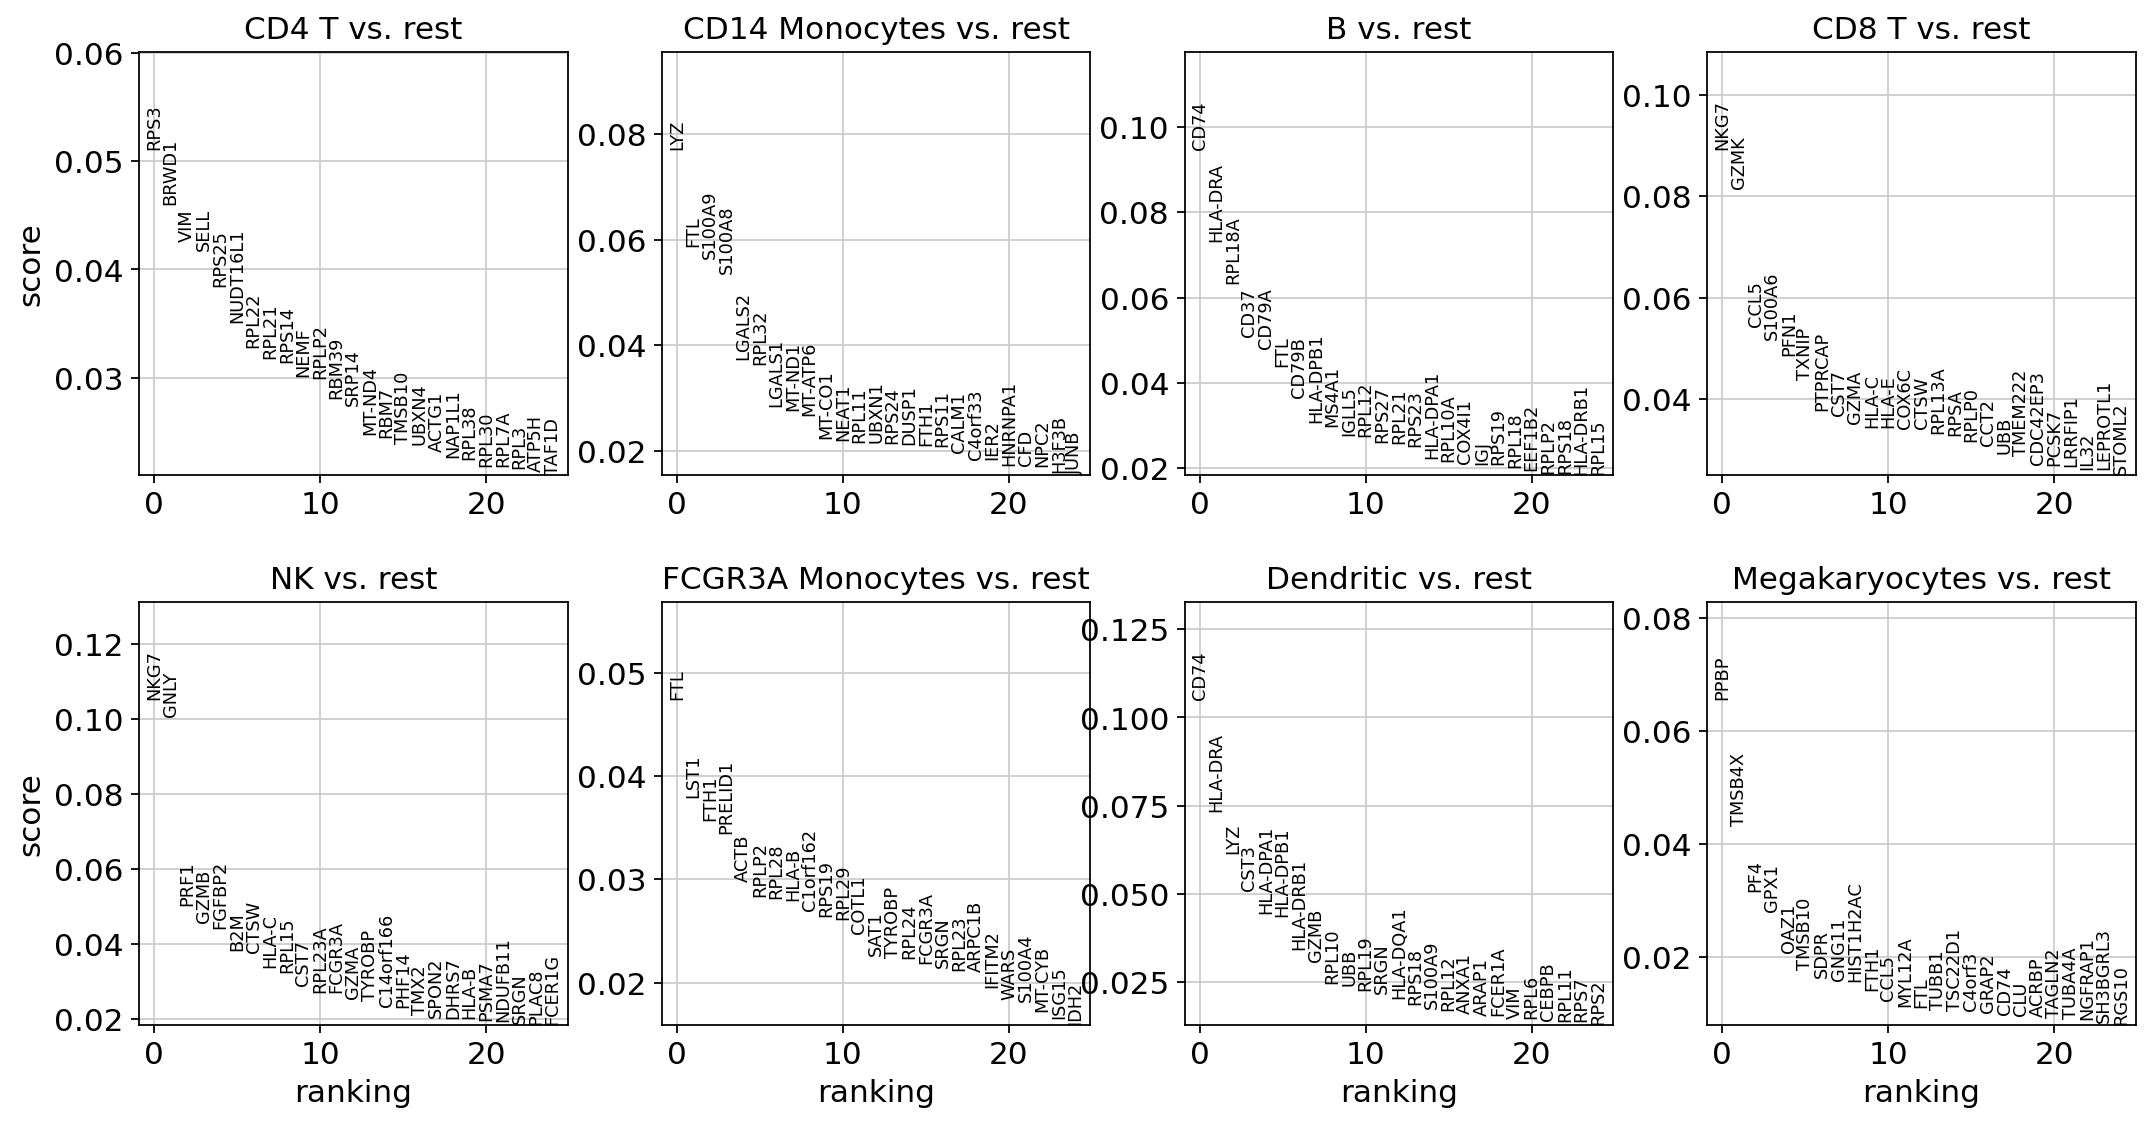

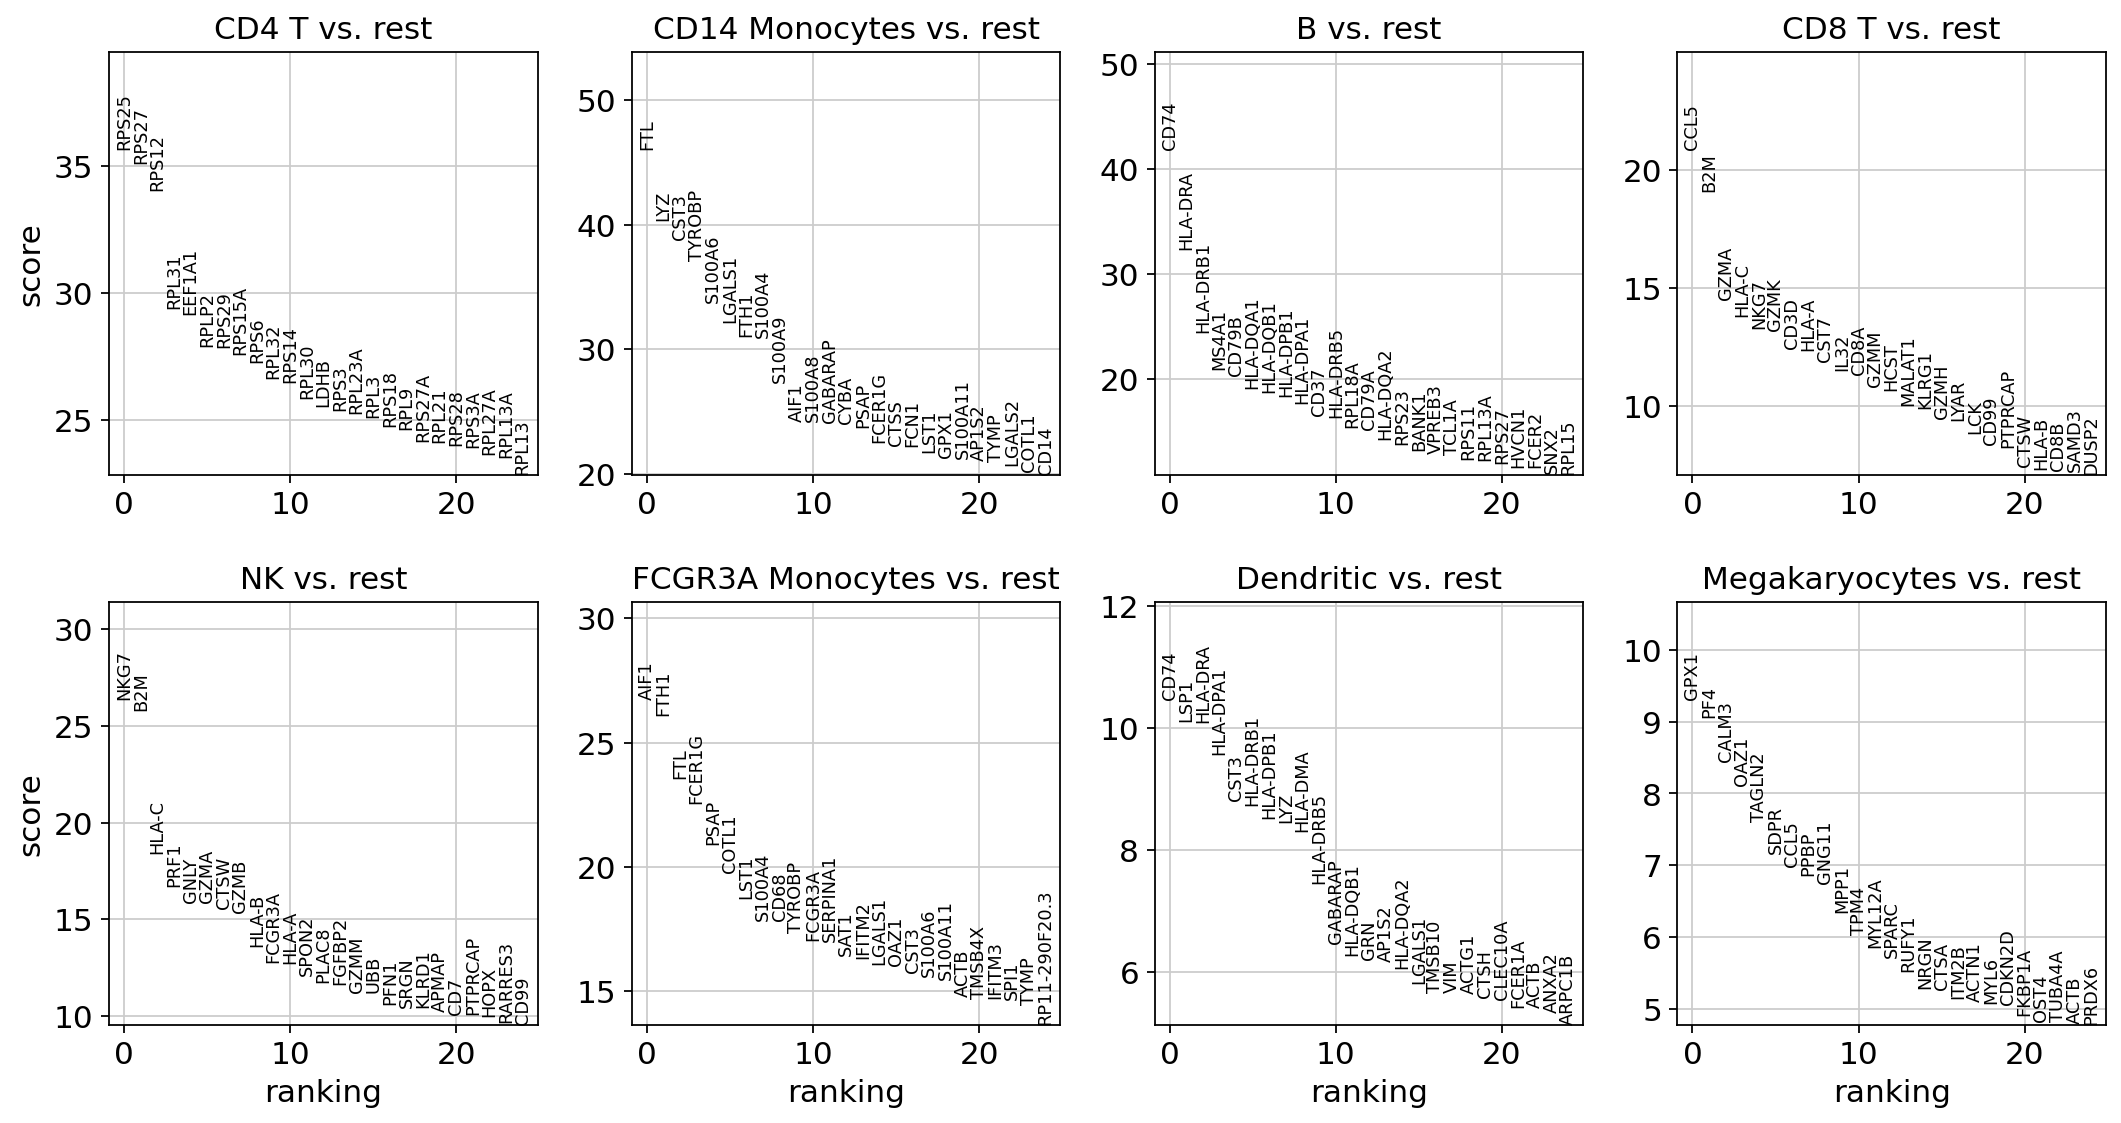

In [19]:
rank_genes_groups_wilcox, rank_genes_groups_logreg,rank_genes_groups_t_test = sctl.tl.rank_genes(pbmc3k_sctl_DATASET.adata,
               wilcox=True,logreg=True,t_test=True,rank_use_raw=True,obs_key="Cell_Clusters_Named",**parameters
                 )

## run sctl.tl.GSEA_enrichr_all_clusters() 


In [20]:
sctl.tl.GSEA_enrichr_all_clusters(test_library_names=['GO_Biological_Process_2021','GO_Cellular_Component_2021','GO_Molecular_Function_2021'],
 top_nth=10,**parameters )

2025-04-29 17:26:25,259 | sctl.tl._functions_4_scanpy | INFO | logreg: the full_table  is 13714 genes long by 8 columns for 8 clusters
2025-04-29 17:26:25,261 | sctl.tl._functions_4_scanpy | INFO | logreg: the foreground list is 1371 genes long
2025-04-29 17:26:25,267 | sctl.tl._functions_4_scanpy | INFO | <CLUSTER 0> for logreg gene rank top 3 background genes ['RPS3', 'BRWD1', 'VIM'], bottom 3 background genes ['HLA-DRA', 'CD74', 'NKG7'] 
2025-04-29 17:26:25,268 | sctl.tl._functions_4_scanpy | INFO | <CLUSTER 0> for logreg gene rank top 3 foreground genes ['RPS3', 'BRWD1', 'VIM'], bottom 3 foreground genes ['CLK4', 'RASSF3', 'FAM104A'] 
2025-04-29 17:26:30,873 | sctl.tl._functions_4_scanpy | INFO | <CLUSTER 1> for logreg gene rank top 3 background genes ['LYZ', 'FTL', 'S100A9'], bottom 3 background genes ['RPL29', 'RPL18A', 'PRELID1'] 
2025-04-29 17:26:30,875 | sctl.tl._functions_4_scanpy | INFO | <CLUSTER 1> for logreg gene rank top 3 foreground genes ['LYZ', 'FTL', 'S100A9'], botto